In [ ]:
# CELL 1 - Upload and Load Dataset
import pandas as pd
from google.colab import files

uploaded = files.upload()  # A button will appear — upload your CSV file

df = pd.read_csv('Banglore_traffic_Dataset.csv')

print("✅ Dataset Loaded!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(df.head())

Saving Banglore_traffic_Dataset.csv to Banglore_traffic_Dataset.csv
✅ Dataset Loaded!
Rows: 8936, Columns: 16
         Date    Area Name Road/Intersection Name  Traffic Volume  \
0  2022-01-01  Indiranagar          100 Feet Road           50590   
1  2022-01-01  Indiranagar               CMH Road           30825   
2  2022-01-01   Whitefield    Marathahalli Bridge            7399   
3  2022-01-01  Koramangala    Sony World Junction           60874   
4  2022-01-01  Koramangala          Sarjapur Road           57292   

   Average Speed  Travel Time Index  Congestion Level  \
0      50.230299           1.500000        100.000000   
1      29.377125           1.500000        100.000000   
2      54.474398           1.039069         28.347994   
3      43.817610           1.500000        100.000000   
4      41.116763           1.500000        100.000000   

   Road Capacity Utilization  Incident Reports  Environmental Impact  \
0                 100.000000                 0              

In [ ]:
# CELL 2A - Basic Info
print("=== Shape ===")
print(df.shape)

print("\n=== Column Names ===")
print(df.columns.tolist())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Shape ===
(8936, 16)

=== Column Names ===
['Date', 'Area Name', 'Road/Intersection Name', 'Traffic Volume', 'Average Speed', 'Travel Time Index', 'Congestion Level', 'Road Capacity Utilization', 'Incident Reports', 'Environmental Impact', 'Public Transport Usage', 'Traffic Signal Compliance', 'Parking Usage', 'Pedestrian and Cyclist Count', 'Weather Conditions', 'Roadwork and Construction Activity']

=== Data Types ===
Date                                   object
Area Name                              object
Road/Intersection Name                 object
Traffic Volume                          int64
Average Speed                         float64
Travel Time Index                     float64
Congestion Level                      float64
Road Capacity Utilization             float64
Incident Reports                        int64
Environmental Impact                  float64
Public Transport Usage                float64
Traffic Signal Compliance             float64
Parking Usage       

In [ ]:
# CELL 2B - Statistics & Distributions
print("=== Basic Statistics ===")
print(df.describe().round(2))

print("\n=== Congestion Level Distribution ===")
print(f"Min : {df['Congestion Level'].min():.2f}")
print(f"Max : {df['Congestion Level'].max():.2f}")
print(f"Mean: {df['Congestion Level'].mean():.2f}")
print(f"Std : {df['Congestion Level'].std():.2f}")

print("\n=== Unique Areas ===")
print(df['Area Name'].unique())

print("\n=== Weather Conditions ===")
print(df['Weather Conditions'].value_counts())

print("\n=== Roadwork Activity ===")
print(df['Roadwork and Construction Activity'].value_counts())


=== Basic Statistics ===
       Traffic Volume  Average Speed  Travel Time Index  Congestion Level  \
count         8936.00        8936.00            8936.00           8936.00   
mean         29236.05          39.45               1.38             80.82   
std          13001.81          10.71               0.17             23.53   
min           4233.00          20.00               1.00              5.16   
25%          19413.00          31.78               1.24             64.29   
50%          27600.00          39.20               1.50             92.39   
75%          38058.50          46.64               1.50            100.00   
max          72039.00          89.79               1.50            100.00   

       Road Capacity Utilization  Incident Reports  Environmental Impact  \
count                    8936.00           8936.00               8936.00   
mean                       92.03              1.57                108.47   
std                        16.58              1.42   

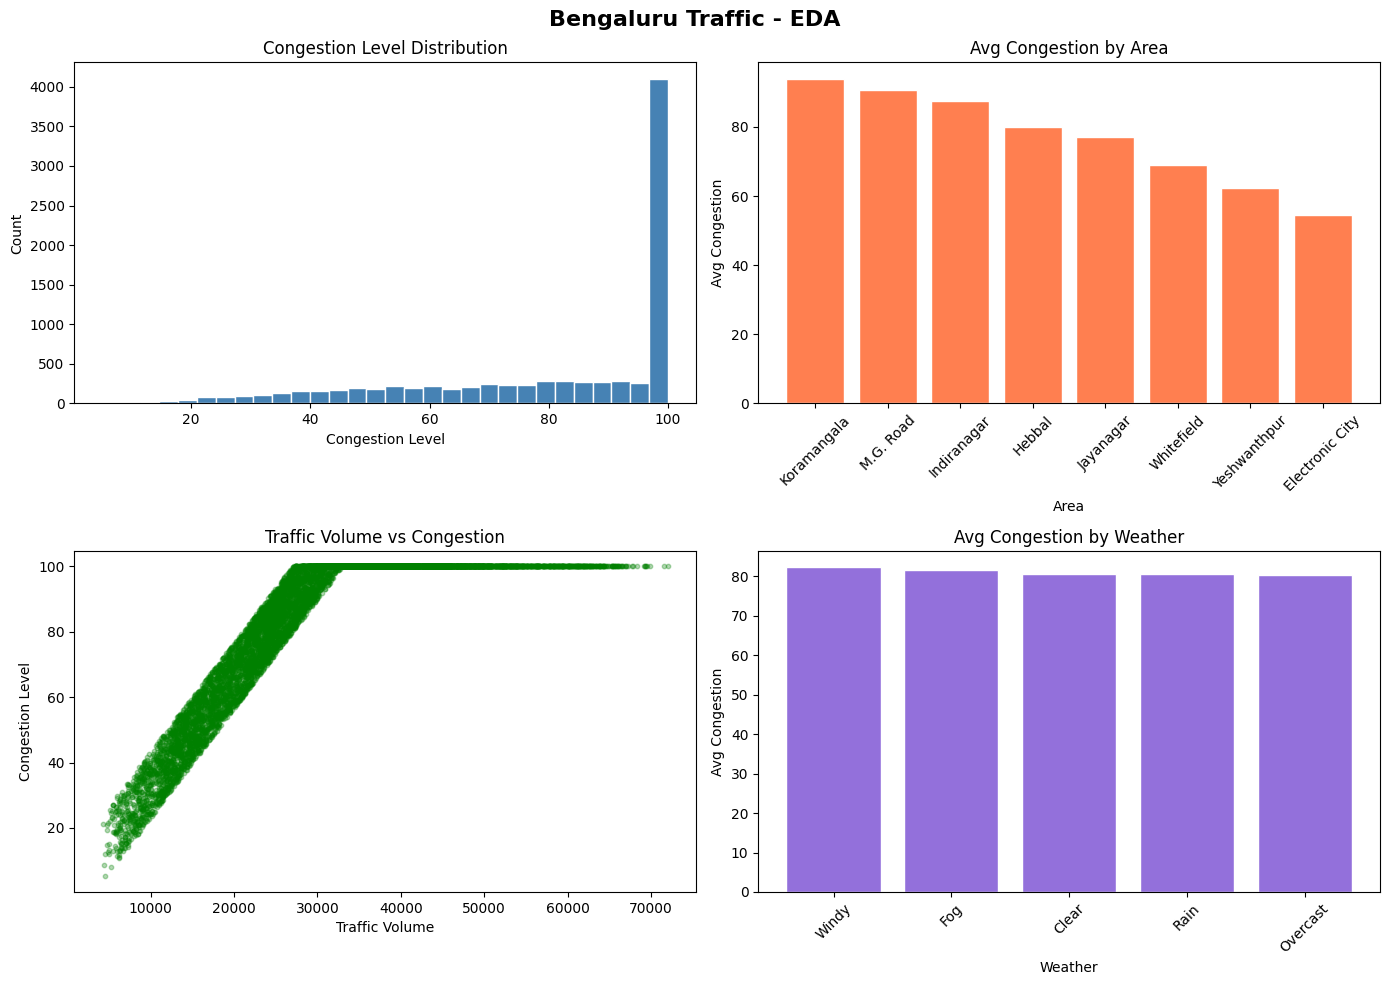

✅ EDA plots saved!


In [ ]:
# CELL 2C - Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bengaluru Traffic - EDA', fontsize=16, fontweight='bold')

# Plot 1 - Congestion Level Distribution
axes[0,0].hist(df['Congestion Level'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('Congestion Level Distribution')
axes[0,0].set_xlabel('Congestion Level')
axes[0,0].set_ylabel('Count')

# Plot 2 - Average Congestion by Area
area_congestion = df.groupby('Area Name')['Congestion Level'].mean().sort_values(ascending=False)
axes[0,1].bar(area_congestion.index, area_congestion.values, color='coral', edgecolor='white')
axes[0,1].set_title('Avg Congestion by Area')
axes[0,1].set_xlabel('Area')
axes[0,1].set_ylabel('Avg Congestion')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3 - Traffic Volume vs Congestion
axes[1,0].scatter(df['Traffic Volume'], df['Congestion Level'],
                  alpha=0.3, color='green', s=10)
axes[1,0].set_title('Traffic Volume vs Congestion')
axes[1,0].set_xlabel('Traffic Volume')
axes[1,0].set_ylabel('Congestion Level')

# Plot 4 - Congestion by Weather
weather_congestion = df.groupby('Weather Conditions')['Congestion Level'].mean().sort_values(ascending=False)
axes[1,1].bar(weather_congestion.index, weather_congestion.values, color='mediumpurple', edgecolor='white')
axes[1,1].set_title('Avg Congestion by Weather')
axes[1,1].set_xlabel('Weather')
axes[1,1].set_ylabel('Avg Congestion')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved!")

In [ ]:
# CELL 3A — Extract date features & drop unnecessary columns
import pandas as pd
import numpy as np

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract useful time features
df['hour'] = df['Date'].dt.hour
df['day_of_week'] = df['Date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['month'] = df['Date'].dt.month

print("✅ Date features extracted!")
print(df[['Date', 'hour', 'day_of_week', 'month']].head())

✅ Date features extracted!
        Date  hour  day_of_week  month
0 2022-01-01     0            5      1
1 2022-01-01     0            5      1
2 2022-01-01     0            5      1
3 2022-01-01     0            5      1
4 2022-01-01     0            5      1


In [ ]:
# CELL 3B — Encode categorical columns & select features
from sklearn.preprocessing import LabelEncoder

le_area = LabelEncoder()
le_weather = LabelEncoder()
le_roadwork = LabelEncoder()

df['Area_encoded'] = le_area.fit_transform(df['Area Name'])
df['Weather_encoded'] = le_weather.fit_transform(df['Weather Conditions'])
df['Roadwork_encoded'] = le_roadwork.fit_transform(df['Roadwork and Construction Activity'])

print("✅ Encoding done!")
print("\nArea mapping:")
for i, name in enumerate(le_area.classes_):
    print(f"  {i} = {name}")

print("\nWeather mapping:")
for i, name in enumerate(le_weather.classes_):
    print(f"  {i} = {name}")

print("\nRoadwork mapping:")
for i, name in enumerate(le_roadwork.classes_):
    print(f"  {i} = {name}")

✅ Encoding done!

Area mapping:
  0 = Electronic City
  1 = Hebbal
  2 = Indiranagar
  3 = Jayanagar
  4 = Koramangala
  5 = M.G. Road
  6 = Whitefield
  7 = Yeshwanthpur

Weather mapping:
  0 = Clear
  1 = Fog
  2 = Overcast
  3 = Rain
  4 = Windy

Roadwork mapping:
  0 = No
  1 = Yes


In [ ]:
# CELL 3C — Build final feature set & normalize target
# Select only the useful columns
features = [
    'Traffic Volume',
    'Average Speed',
    'Travel Time Index',
    'Road Capacity Utilization',
    'Incident Reports',
    'Area_encoded',
    'Weather_encoded',
    'Roadwork_encoded',
    'day_of_week',
    'month'
]

target = 'Congestion Level'

X = df[features]
y = df[target] / 100  # Normalize 0-100 → 0-1

print("✅ Features & Target ready!")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\ny range: {y.min():.3f} to {y.max():.3f}")
print(f"\nFeature columns:\n{X.columns.tolist()}")
print(f"\nFirst 5 rows of X:")
print(X.head())

✅ Features & Target ready!

X shape: (8936, 10)
y shape: (8936,)

y range: 0.052 to 1.000

Feature columns:
['Traffic Volume', 'Average Speed', 'Travel Time Index', 'Road Capacity Utilization', 'Incident Reports', 'Area_encoded', 'Weather_encoded', 'Roadwork_encoded', 'day_of_week', 'month']

First 5 rows of X:
   Traffic Volume  Average Speed  Travel Time Index  \
0           50590      50.230299           1.500000   
1           30825      29.377125           1.500000   
2            7399      54.474398           1.039069   
3           60874      43.817610           1.500000   
4           57292      41.116763           1.500000   

   Road Capacity Utilization  Incident Reports  Area_encoded  Weather_encoded  \
0                 100.000000                 0             2                0   
1                 100.000000                 1             2                0   
2                  36.396525                 0             6                0   
3                 100.000000    

In [ ]:
# CELL 4A — Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% training, 20% testing
    random_state=42     # same split every time you run
)

print("✅ Data Split Done!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

✅ Data Split Done!
Training samples : 7148
Testing  samples : 1788
Features         : 10


In [ ]:
# CELL 4B — Train the Random Forest Model
from sklearn.ensemble import RandomForestRegressor
import time

print("⏳ Training Random Forest... please wait")

start = time.time()

model = RandomForestRegressor(
    n_estimators=100,    # 100 decision trees
    max_depth=10,        # how deep each tree can go
    random_state=42,     # reproducibility
    n_jobs=-1            # use all CPU cores → faster
)

model.fit(X_train, y_train)

end = time.time()
print(f"✅ Training Complete in {round(end - start, 2)} seconds!")
print(f"Number of trees : {model.n_estimators}")
print(f"Features used   : {model.n_features_in_}")

⏳ Training Random Forest... please wait
✅ Training Complete in 1.63 seconds!
Number of trees : 100
Features used   : 10


In [ ]:
# CELL 4C — Quick Prediction Check
import numpy as np

# Predict on test set
y_pred = model.predict(X_test)

# Show first 10 predictions vs actual
print("✅ Sample Predictions (scaled 0-1):")
print(f"{'Actual':<12} {'Predicted':<12} {'Difference'}")
print("-" * 38)
for actual, predicted in zip(y_test[:10], y_pred[:10]):
    diff = abs(actual - predicted)
    print(f"{actual:<12.3f} {predicted:<12.3f} {diff:.3f}")

print(f"\nOverall prediction range:")
print(f"Actual    → Min: {y_test.min():.3f}, Max: {y_test.max():.3f}")
print(f"Predicted → Min: {y_pred.min():.3f}, Max: {y_pred.max():.3f}")

✅ Sample Predictions (scaled 0-1):
Actual       Predicted    Difference
--------------------------------------
1.000        1.000        0.000
1.000        1.000        0.000
0.791        0.782        0.010
0.738        0.762        0.024
0.600        0.581        0.019
0.875        0.881        0.006
0.565        0.525        0.040
0.844        0.893        0.050
0.790        0.883        0.093
1.000        1.000        0.000

Overall prediction range:
Actual    → Min: 0.131, Max: 1.000
Predicted → Min: 0.139, Max: 1.000


In [ ]:
# CELL 5A — Core Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("   MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"MAE  (Mean Abs Error)  : {mae:.4f}")
print(f"RMSE (Root Mean Sq Err): {rmse:.4f}")
print(f"R²   (Accuracy Score)  : {r2:.4f}")
print("=" * 40)

# Convert back to 0-100 scale for better understanding
print(f"\nIn real congestion scale (0-100):")
print(f"MAE  : ±{mae*100:.2f} congestion points")
print(f"RMSE : ±{rmse*100:.2f} congestion points")

# Grade your model
if r2 >= 0.95:
    grade = "🏆 Excellent"
elif r2 >= 0.90:
    grade = "✅ Very Good"
elif r2 >= 0.80:
    grade = "👍 Good"
else:
    grade = "⚠️ Needs improvement"

print(f"\nModel Grade: {grade}")

   MODEL EVALUATION RESULTS
MAE  (Mean Abs Error)  : 0.0286
RMSE (Root Mean Sq Err): 0.0433
R²   (Accuracy Score)  : 0.9654

In real congestion scale (0-100):
MAE  : ±2.86 congestion points
RMSE : ±4.33 congestion points

Model Grade: 🏆 Excellent


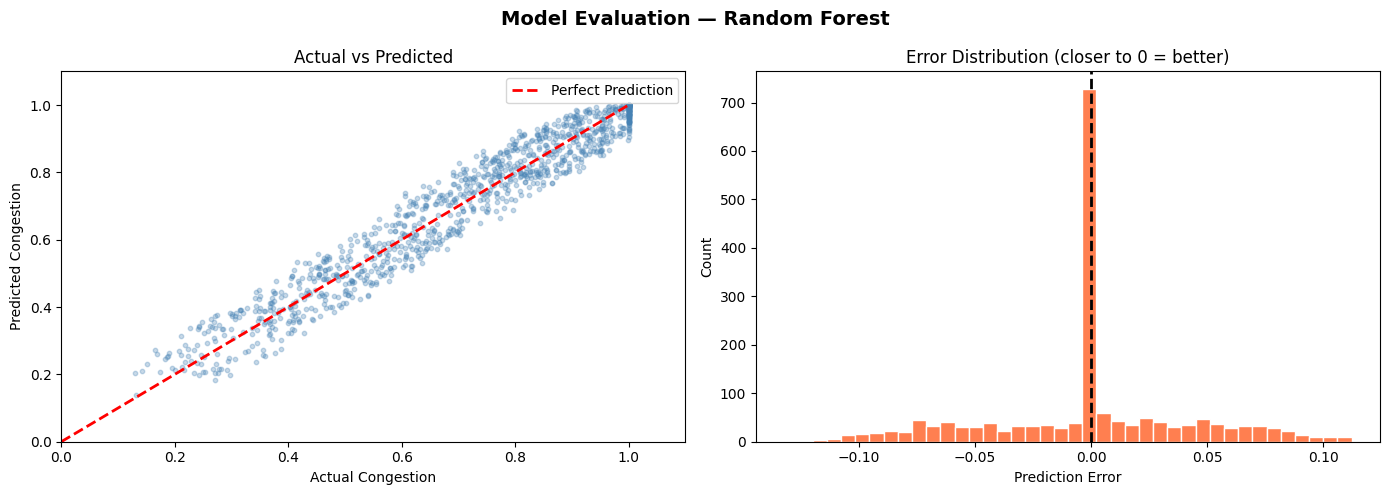

✅ Evaluation plots saved!


In [ ]:
# CELL 5B — Visual Evaluation
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation — Random Forest', fontsize=14, fontweight='bold')

# Plot 1 - Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Congestion')
axes[0].set_ylabel('Predicted Congestion')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()
axes[0].set_xlim(0, 1.1)
axes[0].set_ylim(0, 1.1)

# Plot 2 - Residuals (errors)
residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error')
axes[1].set_ylabel('Count')
axes[1].set_title('Error Distribution (closer to 0 = better)')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation plots saved!")


   FEATURE IMPORTANCE RANKING
                  Feature  Importance
           Traffic Volume    0.978315
Road Capacity Utilization    0.006878
            Average Speed    0.003864
        Travel Time Index    0.002620
         Incident Reports    0.002533
                    month    0.001859
             Area_encoded    0.001401
              day_of_week    0.001356
          Weather_encoded    0.000932
         Roadwork_encoded    0.000242


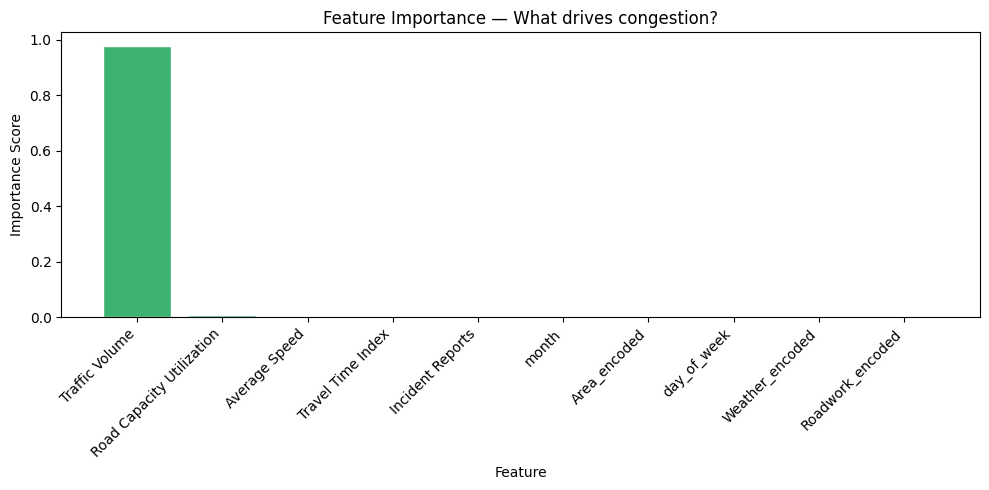

✅ Feature importance saved!


In [ ]:
# CELL 5C — Feature Importance
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("=" * 40)
print("   FEATURE IMPORTANCE RANKING")
print("=" * 40)
print(importance.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(importance['Feature'], importance['Importance'],
        color='mediumseagreen', edgecolor='white')
plt.title('Feature Importance — What drives congestion?')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance saved!")

In [ ]:
import joblib

joblib.dump(model, "traffic_model.joblib")

['traffic_model.joblib']

In [ ]:
from google.colab import files

files.download("traffic_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
joblib.dump(le_area, "area_encoder.joblib")
joblib.dump(le_weather, "weather_encoder.joblib")
joblib.dump(le_roadwork, "roadwork_encoder.joblib")

['roadwork_encoder.joblib']

In [ ]:
files.download("area_encoder.joblib")
files.download("weather_encoder.joblib")
files.download("roadwork_encoder.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib

features = X.columns.tolist()
joblib.dump(features, "features.joblib")

['features.joblib']

In [ ]:
from google.colab import files
files.download("features.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>